# Лекция 6: Image Segmentation

**План лекции:**

1. ~~Постановка задачи~~
3. ~~Метрики~~
4. ~~Функции потерь~~
5. ~~Семантическая сегментация~~
6. Инстанс сегментация
7. Трансформеры в сегментации
8. SAM

# 4. Instance Segmentation

Instance segmentation требует не только классификации пикселей, но и **разделения отдельных объектов одного класса**.  
Разберём ключевые модели с архитектурой и формулами блоков.


## 4.1 Mask R-CNN (He et al., 2017)

Mask R-CNN — это **расширение Faster R-CNN**, предназначенное для **instance segmentation**.  
Он добавляет **маску на пиксельном уровне** к стандартным bounding boxes и class labels.

---

#### Архитектура

![mask-rcnn](assets/mask-rcnn.png)

**Основные блоки:**

1. **Backbone + FPN (Feature Pyramid Network)**

- Backbone (ResNet / ResNeXt) извлекает feature maps из изображения \(I\):

$$
F_b = \{C_2, C_3, C_4, C_5\}
$$

- FPN строит **пирамиду признаков** на разных масштабах (multi-scale):

$$
\begin{aligned}
F_5 &= \mathrm{Conv}_{3\times3}\big(\mathrm{Conv}_{1\times1}(C_5)\big) \\
F_4 &= \mathrm{Conv}_{3\times3}\big(\mathrm{Conv}_{1\times1}(C_4) + \mathrm{Up}(F_5)\big) \\
F_3 &= \mathrm{Conv}_{3\times3}\big(\mathrm{Conv}_{1\times1}(C_3) + \mathrm{Up}(F_4)\big) \\
F_2 &= \mathrm{Conv}_{3\times3}\big(\mathrm{Conv}_{1\times1}(C_2) + \mathrm{Up}(F_3)\big)
\end{aligned}
$$

- $C_l$ — bottom-up feature map на уровне %l%
- $\mathrm{Conv}_{1\times1}$ — lateral connection, чтобы выровнять количество каналов  
- $\mathrm{Up}(F_{l+1})$ — upsample предыдущего top-down уровня  
- $\mathrm{Conv}_{3\times3}$ — сглаживание и подготовка окончательного feature map

$$
F = \text{FPN}(F_b) = \{F_2, F_3, F_4, F_5\}
$$

Эти $F_2, F_3, F_4, F_5$ используются для **RPN и Mask Head**, обеспечивая multi-scale detection.


---

2. **Region Proposal Network (RPN)**

- Генерирует candidate regions (RoIs) с вероятностью, что объект присутствует:

$$
\{B_i\} = \text{RPN}(F)
$$

- Каждое $B_i$ — bounding box: $(x, y, w, h)$
- RPN состоит из:
  - 3×3 conv на feature map
  - 1×1 conv → objectness score + bounding box deltas

---

3. **RoI Align**

- Предыдущий RoI Pooling округлял координаты → потеря точности масок
- RoI Align использует **bilinear interpolation** без округления:

$$
F_i^{\text{roi}} = \text{RoIAlign}(F, B_i, H \times W)
$$

- Output: фиксированный размер $H \times W$ для каждого RoI

---

4. **Mask Head (Extra Branch)**

- Отдельная ветвь для предсказания маски **каждого объекта**:

**ConvBlock**:

$$
\begin{aligned}
x = \text{ReLU}(\text{Conv}_{3×3}(F_i^{\text{roi}}))  \\
x = \text{ReLU}(\text{Conv}_{3×3}(x))  \\
x = \text{ReLU}(\text{Conv}_{3×3}(x))  \\
x = \text{ReLU}(\text{Conv}_{3×3}(x))  \\
x = \text{ReLU}(\text{ConvTranspose}_{2×2}(x))  \\
\end{aligned}
$$

**Финальный слой**:

$$
M_i = \sigma(\text{Conv}_{1×1}(x))
$$

- $M_i \in \mathbb{R}^{H \times W}$ — маска объекта i  
- Предсказывает **вероятность каждого пикселя принадлежать объекту**

---

5. **Bounding Box & Class Head**

- Используются стандартные Faster R-CNN ветви:

$$
C_i = \text{softmax}(\text{FC}(F_i^{\text{roi}})) \quad \text{[class]}
$$
$$
B_i^{\text{pred}} = \text{FC}(F_i^{\text{roi}}) \quad \text{[bounding box]}
$$

---

#### Forward Pass (обобщённо)

1. Изображение → Backbone → FPN → feature maps $F$  
2. RPN → candidate boxes $\{B_i\}$  
3. Для каждого RoI:
   - RoI Align → $F_i^{\text{roi}}$  
   - Mask Head → маска $M_i$  
   - Class + BBox Head → $C_i, B_i^{\text{pred}}$

---

#### Loss функция

Mask R-CNN оптимизируется **комбинированной loss**:

$$
\mathcal{L} = \mathcal{L}_{\text{cls}} + \mathcal{L}_{\text{bbox}} + \mathcal{L}_{\text{mask}}
$$

- $\mathcal{L}_{\text{cls}}$: cross-entropy для классов  
- $\mathcal{L}_{\text{bbox}}$: smooth L1 loss для координат  
- $\mathcal{L}_{\text{mask}}$: pixel-wise binary cross-entropy между предсказанной и GT маской

---

#### Плюсы

- Очень точное разделение экземпляров  
- Multi-scale detection через FPN  
- RoI Align улучшает маски на пиксельном уровне

#### Минусы

- Heavy: много вычислений на каждое RoI  
- Сложнее в обучении, чем обычная semantic segmentation  
- Inference медленнее, чем anchor-free модели (например, CenterMask)


## 4.2 CenterMask (Lee et al., 2020)

**Идея:** объединить **anchor-free detection** с instance segmentation.

- Основана на **CenterNet** — keypoint-based детектор объектов

#### CenterNet

- CenterNet предсказывает **центры объектов** (keypoints) на feature map.  
- Для каждого объекта генерируется heatmap \(H_c\), где пиксели с высокой вероятностью соответствуют центру объекта:

$$
H_c = \text{sigmoid}(\text{KeypointHead}(F))
$$

- Затем для каждого центра предсказываются размеры объекта (width, height) и иногда offset, чтобы уточнить координаты:

$$
(w, h, \Delta x, \Delta y) = \text{RegressionHead}(F[c])
$$

- CenterNet **без anchor boxes**, что упрощает pipeline и ускоряет inference.  

---

#### CenterMask поверх CenterNet
![centermask](assets/centernet.png)

- Вместо RPN и RoI, как в Mask R-CNN, используется **keypoint detection**  
- Маски генерируются через feature fusion вокруг центров объектов:

$$
M_i = \sigma(\text{MaskHead}(F[c_i]))
$$

- \(M_i\) — маска i-го объекта  
- F — feature map с multi-scale backbone (обычно FPN)  

**Плюсы:**

- Быстро и проще, чем Mask R-CNN  
- Anchor-free → real-time inference  

**Минусы:**

- Иногда хуже на маленьких объектах  
- Требуется аккуратный пост-процессинг масок


## 4.3 TensorMask (Chen et al., 2019)

**Основная идея:**  

- Вместо anchor-based или keypoint-based предсказания масок, TensorMask строит **dense sliding window representation** для всех объектов одновременно.  
- Каждый объект представлен как **4D тензор** $H \times W \times M \times M$:  
  - $H \times W$ — spatial resolution feature map  
  - $M \times M$ — предсказанная маска в этом окне  

---

#### Архитектура

1. **Backbone + FPN** → feature map $F \in \mathbb{R}^{C \times H \times W}$

2. **Sliding window conv**  

- Для каждого окна на feature map предсказываем маску размера \(M \times M\)  
- Формально:  

$$
T_{i,j} = \text{Conv4D}(F[i,j]) \in \mathbb{R}^{M \times M}
$$

- (i,j) — координаты окна на feature map  
- Conv4D объединяет информацию по каналам и spatial позиции → маска для этого окна

---

3. **Dense mask prediction**  

- Все окна формируют **4D тензор**:

$$
T \in \mathbb{R}^{H \times W \times M \times M}
$$

- Каждый элемент \(T[i,j,:,:]\) — маска объекта, если объект присутствует в окне (i,j)  
- Если несколько объектов перекрываются, их маски суммируются / объединяются через post-processing  

---

#### Forward pass (упрощённо)

1. Изображение → Backbone → FPN → feature map \(F\)  
2. Для каждой позиции (i,j) на feature map:  
   - Конволюция → 4D tensor → маска \(M \times M\)  
3. После всего feature map:  
   - Получаем dense 4D тензор \(T\)  
4. Post-processing → отбираем отдельные объекты → финальные маски

---

#### Преимущества TensorMask

- Позволяет **обрабатывать перекрывающиеся объекты**, не используя RoI Align  
- End-to-end обучение  
- Dense representation → точные маски

---

#### Минусы

- Большой memory footprint → 4D тензор может быть очень тяжёлым  
- Медленнее, чем anchor-free модели (CenterMask)  
- Требует аккуратного post-processing (суперпозиция масок, NMS)

---

#### Смысл

- В отличие от Mask R-CNN: нет RPN, нет RoI  
- В отличие от CenterMask: маски не зависят только от центров → предсказываются **для всех окон feature map сразу**  


In [12]:
import torch
import torch.nn as nn

class SimpleConv4D(nn.Module):
    def __init__(self, in_channels: int, M: int) -> None:
        super().__init__()
        self.M = M
        # Используем обычный Conv2d с выходом M*M каналов, потом reshape
        self.conv = nn.Conv2d(in_channels, M*M, kernel_size=3, padding=1)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W)
        out = self.conv(x)  # (B, M*M, H, W)
        B, _, H, W = out.shape
        out = out.view(B, H, W, self.M, self.M)  # 4D тензор: (B, H, W, M, M)
        return out

# Пример использования
B, C, H, W = 2, 256, 20, 20
M = 8  # размер маски
feature_map = torch.randn(B, C, H, W)

conv4d = SimpleConv4D(C, M)
mask_tensor = conv4d(feature_map)  # (B, H, W, M, M)
print(mask_tensor.shape)

torch.Size([2, 20, 20, 8, 8])


## 4.4 Deep Watershed Transform (Bai & Urtasun, 2017)

Deep Watershed Transform (DWT) — метод сегментации объектов, который сочетает классический **Watershed алгоритм** с нейросетевой предсказательной моделью. Этот подход позволяет **разделять перекрывающиеся объекты** без необходимости вручную выделять их центры или использовать RoI.


#### Классический Watershed алгоритм

![watershed](assets/watershed.png)

**Идея:**
- Рассматриваем изображение как **топографическую карту**:
  - Тёмные области → низины
  - Светлые области → возвышения
- **Минимумы** низин считаются центрами объектов.
- Начинаем «заливку водой» из минимальных точек.
- Когда «вода» из двух минимальных точек встречается — ставится **граница между объектами**.

**Технически:**
- Берём градиент изображения (часто используют Sobel, чтобы выделить края объектов).
- Локальные минимумы в градиенте → центры объектов, где градиент минимальный (то есть пиксели «похожи внутри объекта»).
- Вода «растёт» из этих точек, заливая пиксели до тех пор, пока «разные котлованы» не встретятся → границы.

---

#### Проблемы классического Watershed

- Чувствителен к шуму → появляется слишком много маленьких сегментов
- Сложно работать с плотными объектами
- Не использует контекст изображения

---

### Deep Watershed Transform (DWT)

![deep_watershed](assets/deep_watershed.png)


**Основная идея:**
- Использовать CNN (часто Unet), чтобы предсказывать **energy map**, где:
  - Минимумы → центры объектов
  - Высокие значения → границы объектов
- После этого применяем **Watershed**, чтобы получить отдельные сегменты объектов.

**Пошагово:**

1. **CNN предсказывает energy map**
   - На выходе карта \(E(x,y)\) того же размера, что и изображение.
   - Минимумы → центры объектов, высокие значения → границы.

2. **Watershed на energy map**
   - Начинаем «заливку» из центров объектов (минимумов)
   - Когда воды встречаются → появляются границы

3. **Результат:** сегментированные объекты

---

#### Почему минимумы в центрах объектов?

- Если минимум был бы на границе, «вода» слилась бы с соседним объектом → объекты не разделились бы.
- Минимумы в центрах создают **отдельные котлованы** → границы формируются автоматически между ними.

---

#### Схема работы Deep Watershed Transform
```
Input Image
     │
     ▼
   UNet predicts
   Energy Map
     │
     ▼
Watershed Transform
     │
     ▼
Segmented Objects
```
---

#### Преимущества DWT

- End-to-end сегментация без ручной разметки центров
- Хорошо разделяет перекрывающиеся объекты
- Энерджи-карта делает процесс устойчивым к шуму

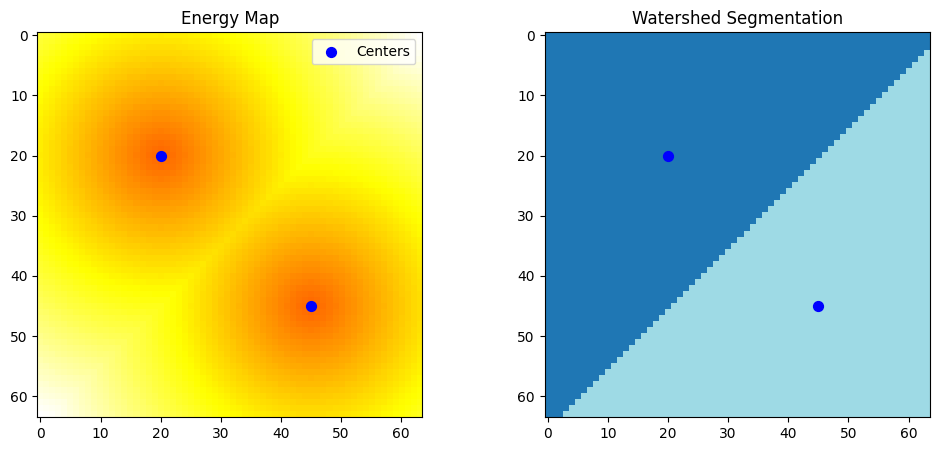

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import watershed

# Размер карты
H, W = 64, 64

# Создаём пустую energy map (высокие значения = границы, низкие = центры объектов)
energy_map = np.ones((H, W))

# Задаём центры объектов
center1 = (20, 20)
center2 = (45, 45)

# Минимумы для центров объектов
energy_map[center1] = 0
energy_map[center2] = 0

# Добавим небольшие "возвышения" между центрами (чтобы Watershed видел границу)
for i in range(H):
    for j in range(W):
        # Простая линейная градиентная "гора" между центрами
        d1 = np.hypot(i - center1[0], j - center1[1])
        d2 = np.hypot(i - center2[0], j - center2[1])
        energy_map[i, j] += min(d1, d2) / 50  # чем дальше от центра, тем выше

# Создаём markers (каждому объекту своя метка)
markers = np.zeros_like(energy_map, dtype=int)
markers[center1] = 1
markers[center2] = 2

# Применяем Watershed
labels = watershed(energy_map, markers=markers)

# Визуализация
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Energy Map")
plt.imshow(energy_map, cmap='hot')
plt.scatter([center1[1], center2[1]], [center1[0], center2[0]], color='blue', s=50, label='Centers')
plt.legend()

plt.subplot(1,2,2)
plt.title("Watershed Segmentation")
plt.imshow(labels, cmap='tab20')
plt.scatter([center1[1], center2[1]], [center1[0], center2[0]], color='blue', s=50)
plt.show()

# 5. Transformers in Segmentation

## 5.1 Vision Transformer (ViT) + Decoder

#### Напоминание о ViT

**Vision Transformer (ViT)** обрабатывает изображение, разбивая его на **патчи** размером $P \times P$ и проецируя каждый в embedding размерности $D$:

$$
x_p = \text{Flatten}(I_p) W_e
$$

- Последовательность патчей формирует вход для **Transformer Encoder**.
- Внутри encoder применяется **Multi-Head Self-Attention (MHSA)** с residual connections:
$$
z_l' = z_{l-1} + \text{MHSA}(\text{LN}(z_{l-1})), \quad
z_l = z_l' + \text{MLP}(\text{LN}(z_l'))
$$
 

---

#### Decoder для сегментации

Главная задача сегментации — восстановить **пространственное разрешение** и получить точные маски объектов.

1. **Reshape патчей**
   - Выход encoder $Z \in \mathbb{R}^{N \times D}$ преобразуется обратно в 2D решётку:
$$
Z \in \mathbb{R}^{N \times D} \rightarrow \mathbb{R}^{H/P \times W/P \times D}
$$

2. **Upsampling**
   - Для получения оригинального разрешения $H \times W$ применяются последовательные слои:
     - Upsampling (nearest, bilinear)
     - Convolution (для уточнения границ)
     - BatchNorm / LayerNorm
     - Non-linearity (ReLU)

3. **Skip Connections**
   - При необходимости можно соединять intermediate features (например, из ранних слоёв encoder или CNN backbone), чтобы восстановить мелкие детали объектов.

4. **Выходная маска**
   - На последнем слое decoder предсказывает **классы для каждого пикселя**:
$$
\text{Segmentation Mask} \in \mathbb{R}^{H \times W \times C_{classes}}
$$

---

#### Pipeline сегментации


```
Input Image (H x W x C)
        │
     Patch Embedding
        │
 Transformer Encoder (sequence of N patches, D dim)
        │
      Reshape → 2D map (H/P x W/P x D)
        │
Upsampling + Conv + Refinement
        │
 Skip Connections / Multi-scale fusion
        │
Segmentation Mask (H x W x C_classes)
```
---

#### Ключевые моменты

- ViT обеспечивает **глобальный контекст**.
- Decoder отвечает за **точные пространственные маски**.
- Skip connections и multi-scale features помогают восстановить мелкие объекты.
- Можно комбинировать с CNN для улучшения локальных признаков (hybrid ViT + decoder).


## 5.2 Segmenter with Transformer (SETR, 2021, Xiao et al.)

![setr](assets/setr.png)

Главная особенность SETR — **точное восстановление пространственного разрешения** с использованием разных стратегий декодирования.  

#### 1. ViT encoder
   - Выход ViT encoder: $Z \in \mathbb{R}^{N \times D}$
   - Reshape в 2D feature map:
$$
Z_{2D} \in \mathbb{R}^{H/P \times W/P \times D}
$$

#### 2. Decoder в SETR

Варианты decoder:

- **PUP (Progressive Upsampling)**
  - Последовательное увеличение разрешения на каждом слое:
$$
F_{i+1} = \text{Upsample}(F_i) + \text{Conv}(F_i)
$$
  - Каждый уровень уточняет детали, постепенно приближая размер к исходному H×W
- **MLA (Multi-Layer Aggregation)**
  - Объединяет признаки из нескольких слоёв encoder:
$$
F_{agg} = \sum_{l \in L} w_l \cdot \text{Reshape}(Z_l)
$$
  - Позволяет учитывать разные уровни абстракции: глобальные и локальные признаки

3. **Upsampling + Refinement**
  - После PUP/MLA применяются conv слои для уточнения масок
  - Опционально добавляются **skip connections**, чтобы восстановить мелкие детали объектов

4. **Выходная маска**
$$
\text{Segmentation Mask} \in \mathbb{R}^{H \times W \times C_{classes}}
$$

---

#### Pipeline сегментации

$$
\text{Input Image} \rightarrow \text{ViT Encoder} \rightarrow \text{Reshape → PUP/MLA Decoder → Conv} \rightarrow \text{Segmentation Mask}
$$

---

#### Ключевые моменты

- PUP и MLA — это основные стратегии для восстановления пространственной структуры
- SETR хорошо справляется с мелкими объектами за счёт progressive upsampling и multi-scale aggregation
- Decoder отвечает за точность масок, ViT encoder — за глобальный контекст
- Можно комбинировать с CNN для улучшения локальных деталей (hybrid models)

---

#### Плюсы

- Высокое качество сегментации мелких объектов
- Сохраняется глобальный контекст благодаря Transformer encoder
- Multi-scale aggregation улучшает точность

#### Минусы

- Дорогой в вычислениях из-за больших embedding и многослойного decoder
- Требует много видеопамяти для высоких разрешений
- Настройка PUP/MLA сложнее, чем простой MLP decoder

## 5.3 Segmentation Transformer (SegFormer, 2021, Xie et al.)

SegFormer — это современная архитектура для сегментации изображений, которая сочетает **иерархический transformer encoder** с **лёгким decoder**.  
В отличие от ViT и SETR, SegFormer не использует глобальный последовательный transformer; multi-scale признаки формируются **уже на этапе кодирования**, а decoder минималистичный.

![segformer](assets/segformer.png)

---

#### Encoder: Hierarchical Transformer

Encoder SegFormer строится **иерархически** на 4 уровнях, каждый уровень уменьшает разрешение feature map и увеличивает абстракцию признаков:

$$
\text{Feature map resolutions: } \{H/4 \times W/4, \; H/8 \times W/8, \; H/16 \times W/16, \; H/32 \times W/32\}
$$

- Каждый уровень обрабатывает свои **patch embeddings** с размерностью D
- Вместо глобальной attention, как в ViT/SETR, используется **локальная self-attention**:
  1. Feature map $F_i \in \mathbb{R}^{H_i \times W_i \times D}$ разбивается на окна размером $w \times w$
  2. Для каждого окна вычисляется attention:
$$
\text{Attention}_\text{local}(Q_w,K_w,V_w) = \text{Softmax}\Big(\frac{Q_w K_w^T}{\sqrt{d_k}}\Big) V_w
$$
где $Q_w,K_w,V_w \in \mathbb{R}^{w^2 \times D}$

- После всех окон выходы объединяются обратно в feature map того же размера $H_i \times W_i \times D$
- Multi-scale признаки формируются **на этапе кодирования**, что позволяет decoder быть лёгким.

**Особенности encoder:**

- Экономит память и вычисления $(w^2 \ll N)$ 
- Сохраняет локальные детали каждого уровня  
- Иерархический подход обеспечивает достаточный **глобальный контекст**, даже при локальной attention

**Выход encoder:**  
$$
F_1, F_2, F_3, F_4 \quad \text{с соответствующими разрешениями}
$$

---

#### Decoder: MLP + Upsampling

Decoder в SegFormer простой и эффективный, так как encoder уже дал multi-scale признаки.

**Шаги обработки:**

1. **MLP Projection**  
   - Каждое feature map уровня \(i\) проецируется в общее embedding пространство \(D\):
$$
F_i' = \text{MLP}(F_i), \quad F_i' \in \mathbb{R}^{H_i \times W_i \times D}
$$

2. **Upsampling**  
   - Все $F_i'$ увеличиваются до разрешения самой крупной карты (H/4 × W/4):
$$
F_i^{up} = \text{Upsample}(F_i')
$$

3. **Fusion**  
   - Объединяем все уровни через суммирование или конкатенацию:
$$
F_{fusion} = \sum_{i=1}^{4} F_i^{up}
$$

4. **Segmentation Head**  
   - Лёгкий conv слой преобразует fused features в маску:
$$
\text{Segmentation Mask} \in \mathbb{R}^{H \times W \times C_{classes}}
$$

**Особенности decoder:**

- Минималистичный, без skip connections  
- Multi-scale признаки уже учтены encoder’ом  
- Подходит для real-time сегментации

---

#### Pipeline SegFormer

$$
\text{Input Image} \;\rightarrow\; \text{Hierarchical Transformer Encoder (multi-scale features)} \;\rightarrow\; \text{MLP Decoder + Upsampling + Fusion} \;\rightarrow\; \text{Segmentation Mask}
$$

- Encoder: **multi-scale + локальная attention**  
- Decoder: **точная маска + объединение уровней**  

---

#### Ключевые моменты

1. **Hierarchical encoder** создаёт multi-scale признаки сразу  
2. **Локальная self-attention** снижает нагрузку, сохраняет детали  
3. **Лёгкий decoder**: MLP + upsampling + fusion  
4. Отличие от ViT/SETR:  
   - ViT/SETR: глобальный encoder, decoder восстанавливает spatial info  
   - SegFormer: encoder уже multi-scale, decoder минималистичный  
5. Multi-scale признаки позволяют сегментировать **мелкие и крупные объекты одновременно**

---

#### Плюсы

- Лёгкий и эффективный decoder  
- Multi-scale признаки прямо из encoder  
- Подходит для real-time и высоких разрешений  
- Хорошая точность для объектов разных размеров

#### Минусы

- Меньше контроля локальных деталей без skip connections  
- Fusion через суммирование/конкатенацию может быть менее точным на сложных границах  
- Производительность сильно зависит от качества encoder

## 5.4 Mask2Former (2022, Cheng et al.)

**Mask2Former** — универсальная архитектура сегментации, основанная на **query-based prediction**.  
Модель предсказывает **набор масок объектов**, каждая из которых генерируется отдельным **mask query**.

Архитектура поддерживает:

- semantic segmentation
- instance segmentation
- panoptic segmentation


---

#### Общая идея
![mask2former_article](assets/mask2former_article.jpg)
Вместо dense-предсказания класса для каждого пикселя модель использует **набор queries**, которые взаимодействуют с признаками изображения через механизм attention.

Каждый query предсказывает:

- класс объекта
- маску сегментации

Pipeline модели:

$$
I \rightarrow \text{Backbone + Pixel Decoder} \rightarrow F
$$

$$
Q \rightarrow \text{Transformer Decoder}(Q, F)
$$

$$
\rightarrow \text{Class Prediction} + \text{Mask Prediction}
$$

где  

- $I$ — изображение  
- $F$ — многоуровневые признаки изображения  
- $Q$ — mask queries.

---

#### Encoder

Encoder состоит из **backbone** (например, ResNet или Swin Transformer) и **pixel decoder**, который формирует многоуровневые признаки.

$$
F = \text{Encoder}(I)
$$

Обычно используется набор multi-scale feature maps:

$$
F = \{F_1, F_2, F_3, F_4\}
$$

где каждый уровень имеет своё пространственное разрешение.

---

#### Mask Queries

Mask2Former использует набор **learnable query embeddings**:

$$
Q = \{q_1, q_2, ..., q_N\}
$$

где  

- $N$ — число queries  
- $q_i \in \mathbb{R}^D$

Каждый query соответствует **потенциальному объекту или сегментационной области**.

---

#### Transformer Decoder

Decoder обновляет queries через self-attention и cross-attention с признаками изображения.

Для слоя $l$:

$$
Q^{l'} = Q^l + \text{SelfAttention}(Q^l)
$$

$$
Q^{l''} = Q^{l'} + \text{CrossAttention}(Q^{l'}, F)
$$

$$
Q^{l+1} = Q^{l''} + \text{MLP}(Q^{l''})
$$

Attention вычисляется как:

$$
\text{Attention}(Q,K,V)=
\text{Softmax}\left(
\frac{QK^T}{\sqrt{d}}
\right)V
$$

---

#### Mask Prediction

Каждый query генерирует **mask embedding**:

$$
e_i = W_m q_i
$$

Pixel decoder формирует **pixel embeddings** $F_p$ для каждого пикселя.

Маска вычисляется через скалярное произведение:

$$
M_i(x,y) = e_i^\top F_p(x,y)
$$

Финальная вероятность маски:

$$
\hat{M}_i(x,y) = \sigma(M_i(x,y))
$$

---

#### Class Prediction

Класс объекта определяется из представления query:

$$
p_i = \text{Softmax}(W_c q_i)
$$

где $p_i$ — распределение вероятностей по классам.

---

#### Masked Attention

Ключевое улучшение Mask2Former — **masked attention**.

Вместо attention ко всем пикселям внимание ограничивается областью, соответствующей текущему предсказанию маски.

Attention logits модифицируются маской:

$$
A =
\text{Softmax}\left(
\frac{QK^T}{\sqrt{d}} + \mathcal{M}
\right)
$$

где  

- $\mathcal{M}$ — attention mask  
- значения вне области маски имеют большое отрицательное значение.

Это позволяет:

- фокусироваться на релевантной области изображения  
- уменьшить шум в attention  
- повысить эффективность вычислений.

---

#### Matching

Для сопоставления предсказаний и ground truth используется **Hungarian matching**, аналогично DETR.

Каждому объекту сопоставляется один query.

---

#### Функция потерь

![mask2former](assets/mask2former.png)

Общий loss:

$$
\mathcal{L} =
\lambda_{cls}\mathcal{L}_{cls}
+
\lambda_{mask}\mathcal{L}_{mask}
+
\lambda_{dice}\mathcal{L}_{dice}
$$

где  

- $\mathcal{L}_{cls}$ — классификационный loss  
- $\mathcal{L}_{mask}$ — binary cross-entropy loss для маски  
- $\mathcal{L}_{dice}$ — Dice loss.

---

#### Преимущества

- универсальная архитектура сегментации  
- единая модель для semantic / instance / panoptic segmentation  
- masked attention улучшает локализацию объектов

---

#### Недостатки

- сложная архитектура decoder  
- высокие вычислительные требования  
- чувствительность к числу queries

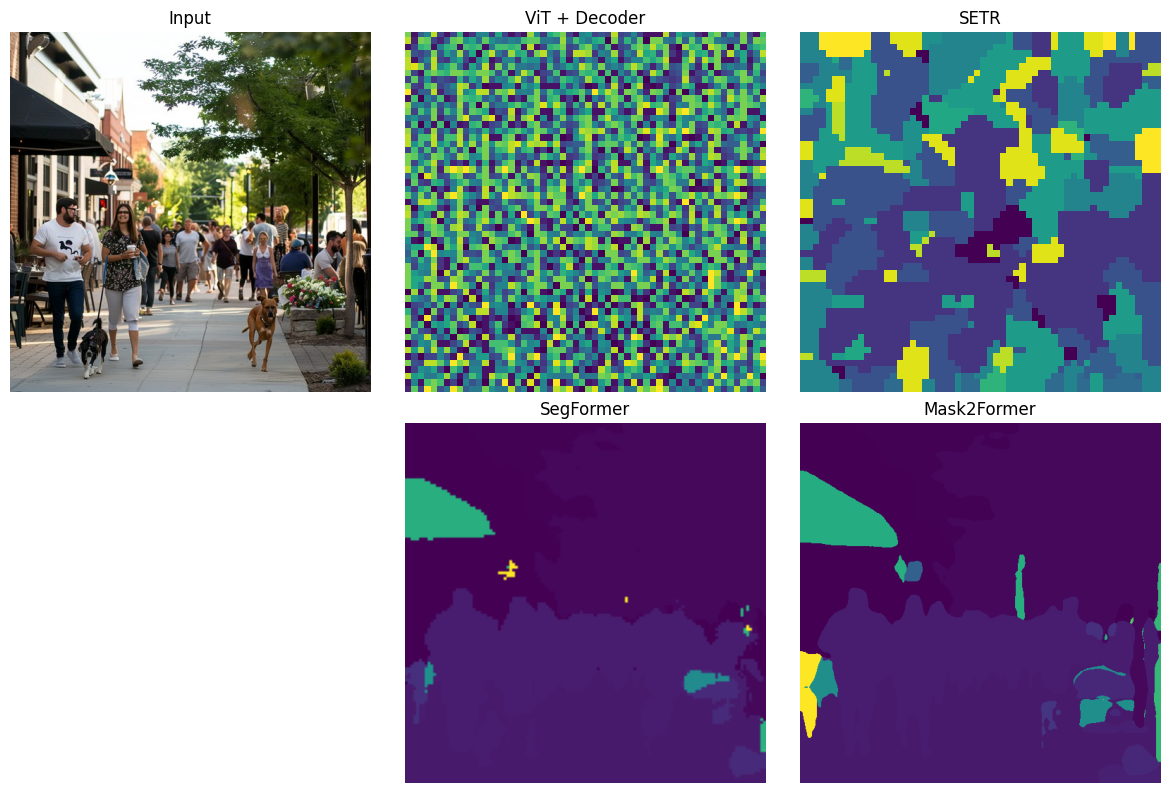

In [34]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from transformers import (
    SegformerImageProcessor,
    SegformerForSemanticSegmentation,
    Mask2FormerImageProcessor,
    Mask2FormerForUniversalSegmentation
)

from typing import Tuple

# ----------------------
# Load and transform image
# ----------------------
image_path = "assets/StockCake-Sidewalk_Dog_Walk-1091895-medium.jpg"
image= Image.open(image_path).convert("RGB")

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

img_tensor = transform(image).unsqueeze(0)  # [1, 3, 224, 224]

# ----------------------
# ViT + simple decoder
# ----------------------
class ViTSegmentation(nn.Module):
    def __init__(self, num_classes: int = 21):
        super().__init__()
        self.encoder = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=0
        )
        dim = self.encoder.embed_dim

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(dim, 256, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(256, num_classes, kernel_size=2, stride=2)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.encoder.forward_features(x)
        if features.shape[1] != int(features.shape[1] ** 0.5) ** 2:
            features = features[:, 1:, :]  # удаляем cls token
        B, N, C = features.shape
        H = W = int(N**0.5)
        features = features.transpose(1,2).reshape(B,C,H,W)
        mask = self.decoder(features)
        return mask

vit_model = ViTSegmentation()
vit_out = vit_model(img_tensor)
vit_mask = vit_out.argmax(dim=1)[0].detach().numpy()

# ----------------------
# SETR (Segmentation Transformer)
# ----------------------
class SETR(nn.Module):
    def __init__(self, num_classes: int = 21):
        super().__init__()
        self.encoder = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=0
        )
        dim = self.encoder.embed_dim

        self.decoder = nn.Sequential(
            nn.Conv2d(dim, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=4, mode="bilinear", align_corners=False),
            nn.Conv2d(256, num_classes, kernel_size=1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.encoder.forward_features(x)
        if features.shape[1] != int(features.shape[1] ** 0.5) ** 2:
            features = features[:, 1:, :]  # удаляем cls token
        B, N, C = features.shape
        H = W = int(N**0.5)
        features = features.transpose(1,2).reshape(B,C,H,W)
        mask = self.decoder(features)
        return mask

setr_model = SETR()
setr_out = setr_model(img_tensor)
setr_mask = setr_out.argmax(dim=1)[0].detach().numpy()

# ----------------------
# SegFormer
# ----------------------
processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512"
)
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512"
)
inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

segformer_mask = outputs.logits.argmax(dim=1)[0].cpu().numpy()

# ----------------------
# Mask2Former
# ----------------------
processor_m2f = Mask2FormerImageProcessor.from_pretrained(
    "facebook/mask2former-swin-base-ade-semantic"
)
model_m2f = Mask2FormerForUniversalSegmentation.from_pretrained(
    "facebook/mask2former-swin-base-ade-semantic"
)
inputs = processor_m2f(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model_m2f(**inputs)

mask2former_mask = processor_m2f.post_process_semantic_segmentation(
    outputs,
    target_sizes=[image.size[::-1]]
)[0]

# ----------------------
# Visualize all results
# ----------------------
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Input")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(vit_mask)
plt.title("ViT + Decoder")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(setr_mask)
plt.title("SETR")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(segformer_mask)
plt.title("SegFormer")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(mask2former_mask)
plt.title("Mask2Former")
plt.axis("off")

plt.tight_layout()
plt.show()